In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.manifold import TSNE
from tqdm import tqdm
import plotly.express as px
from sklearn.model_selection import KFold,cross_val_score,StratifiedKFold

In [2]:
df = pd.read_csv("model_build.csv")

In [3]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

In [4]:
numdf = df[num_cols]

In [5]:
from scipy.stats import norm
import numpy as np
from sklearn.metrics import mean_squared_error

def normality_fit_score(series):
    data = series.dropna()
    mu, std = norm.fit(data)

    # Histogram and fitted normal PDF
    hist, bins = np.histogram(data, bins=20, density=True)
    centers = (bins[:-1] + bins[1:]) / 2
    pdf = norm.pdf(centers, mu, std)

    # Use relative error instead of 1 - MSE
    mse = mean_squared_error(hist, pdf)
    max_mse = mean_squared_error(hist, np.zeros_like(hist)) + 1e-6  # avoid zero division
    score = 1 - (mse / max_mse)  # score between 0 and 1

    return round(score * 100, 2)  # Return as percentage


In [6]:
col = []
norm_score = []
for i in num_cols:
    col.append(i)
    score = normality_fit_score(numdf[i])
    norm_score.append(score)
    print(f"{i}: {score}%")

pct_tl_open_l6m: 16.99%
pct_tl_closed_l6m: 20.49%
tot_tl_closed_l12m: 85.71%
pct_tl_open_l12m: 18.4%
pct_tl_closed_l12m: 19.73%
tot_missed_pmnt: 89.69%
cc_tl: 84.11%
home_tl: 77.76%
pl_tl: 85.93%
secured_tl: 91.51%
unsecured_tl: 67.81%
other_tl: 88.73%
age_oldest_tl: 74.14%
age_newest_tl: 64.65%
time_since_recent_payment: 86.39%
time_since_recent_deliquency: 91.43%
max_delinquency_level: 57.0%
num_deliq_6_12mts: 65.18%
max_deliq_6mts: 79.78%
max_deliq_12mts: 71.49%
num_times_60p_dpd: 71.2%
num_std_12mts: 62.89%
num_sub: 74.29%
num_sub_12mts: 34.08%
num_dbt: 69.88%
num_dbt_12mts: 57.01%
num_lss: 1.88%
recent_level_of_deliq: 62.91%
cc_enq_l12m: 73.34%
pl_enq_l12m: 78.54%
time_since_recent_enq: 84.68%
enq_l3m: 71.12%
netmonthlyincome: 100.0%
time_with_curr_empr: 92.61%
cc_utilization: 42.0%
cc_flag: 10.87%
pl_flag: 7.84%
pct_pl_enq_l6m_of_ever: 9.32%
pct_cc_enq_l6m_of_ever: 15.22%
hl_flag: 6.25%
gl_flag: 14.19%


In [7]:
norm_results = pd.DataFrame({"col_name":col,"norm_value":norm_score})

In [8]:
norm_results.sort_values(by="norm_value",ascending=False)

,col_name,norm_value
32,netmonthlyincome,100.00
33,time_with_curr_empr,92.61
9,secured_tl,91.51
15,time_since_recent_deliquency,91.43
5,tot_missed_pmnt,89.69
11,other_tl,88.73
14,time_since_recent_payment,86.39
8,pl_tl,85.93
2,tot_tl_closed_l12m,85.71
30,time_since_recent_enq,84.68


In [9]:
pd.set_option("display.max_columns",None)
df.shape

(51336, 47)

In [10]:
xtrain,xtest,ytrain,ytest = train_test_split(df.iloc[:,0:46],df.iloc[:,-1],test_size=0.2,random_state=42)

In [11]:
lb = LabelEncoder()
ytrain = lb.fit_transform(ytrain)
ytest = lb.transform(ytest)

In [12]:
transformer = ColumnTransformer(
    [("ordinal",OrdinalEncoder(categories=[["SSC","12TH","UNDER GRADUATE","GRADUATE","POST-GRADUATE","PROFESSIONAL","OTHERS"]],
                    handle_unknown="use_encoded_value",
                    unknown_value= -1,
                    encoded_missing_value=np.nan),["education"]),
     ("onehot",OneHotEncoder(drop="first",sparse_output=False),["maritalstatus","gender","last_prod_enq2","first_prod_enq2"])
]
, remainder="passthrough")

In [82]:
pipe = Pipeline([
    ("pre-processing",transformer),
    ("model",XGBClassifier(n_estimators=140,max_depth=8,subsample=0.3692321814052426,
                           learning_rate=0.2486165415267274,
                           reg_lambda=302,
                           colsample_bylevel=0.6364993625552667,
                           eta=0.9956631118988113,
                           grow_policy="lossguide",
                           min_child_weight=0.43602041607476005 ))
    ])
transformer.set_output(transform="pandas")

c:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinal',
                                 OrdinalEncoder(categories=[['SSC', '12TH',
                                                             'UNDER GRADUATE',
                                                             'GRADUATE',
                                                             'POST-GRADUATE',
                                                             'PROFESSIONAL',
                                                             'OTHERS']],
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['education']),
                                ('onehot',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['maritalstatus', 'gender', 'last_prod_enq2',
                                  'first_prod_enq2'])])

In [29]:
# feature selection using exhaustive feature selection
from mlxtend.feature_selection import SequentialFeatureSelector as efs

In [49]:
from lightgbm import LGBMClassifier

LBG = LGBMClassifier(n_estimators=140,max_depth=8,subsample=0.3692321814052426,
                           learning_rate=0.2486165415267274,
                           reg_lambda=302,
                           colsample_bylevel=0.6364993625552667,
                           eta=0.9956631118988113,
                           grow_policy="lossguide",
                           min_child_weight=0.43602041607476005)

sel = efs(LBG,k_features="best",forward=True,scoring="accuracy",cv=2)


In [50]:
pipe333 = Pipeline([
    ("pre-processing",transformer),
    ("model",sel)])

In [51]:
pipe333.fit(xtrain,ytrain)

c:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: U

Pipeline(steps=[('pre-processing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['SSC',
                                                                              '12TH',
                                                                              'UNDER '
                                                                              'GRADUATE',
                                                                              'GRADUATE',
                                                                              'POST-GRADUATE',
                                                                              'PROFESSIONAL',
                                                                              'OTHERS']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['education']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['maritalst...
                                                   'first_prod_enq2'])])),
                ('model',
                 SequentialFeatureSelector(cv=2,
                                           estimator=LGBMClassifier(colsample_bylevel=0.6364993625552667,
                                                                    eta=0.9956631118988113,
                                                                    grow_policy='lossguide',
                                                                    learning_rate=0.2486165415267274,
                                                                    max_depth=8,
                                                                    min_child_weight=0.43602041607476005,
                                                                    n_estimators=140,
                                                                    reg_lambda=302,
                                                                    subsample=0.3692321814052426),
                                           k_features=(1, 54),
                                           scoring='accuracy'))])

In [56]:
pipe333.named_steps["model"].k_score_

np.float64(0.8044949839290931)

In [74]:
a = []
for i in pipe333.named_steps["model"].k_feature_names_:
    a.append(int(i))

In [ ]:
a

[0,
 1,
 2,
 3,
 5,
 6,
 11,
 12,
 15,
 17,
 19,
 21,
 25,
 26,
 28,
 32,
 34,
 35,
 36,
 38,
 40,
 42,
 43,
 44,
 49,
 50,
 51,
 52]

In [84]:
b = transformer.fit_transform(xtrain)



In [95]:
c = b.iloc[:,a]

In [94]:
from lightgbm import LGBMClassifier

LBG2 = LGBMClassifier(n_estimators=140,max_depth=8,subsample=0.3692321814052426,
                           learning_rate=0.2486165415267274,
                           reg_lambda=302,
                           colsample_bylevel=0.6364993625552667,
                           eta=0.9956631118988113,
                           grow_policy="lossguide",
                           min_child_weight=0.43602041607476005)

In [96]:
LBG2.fit(c,ytrain)

LGBMClassifier(colsample_bylevel=0.6364993625552667, eta=0.9956631118988113,
               grow_policy='lossguide', learning_rate=0.2486165415267274,
               max_depth=8, min_child_weight=0.43602041607476005,
               n_estimators=140, reg_lambda=302, subsample=0.3692321814052426)

In [111]:
[i for i in LBG2.predict_proba(c)[0]]

[np.float64(0.6751149483130711),
 np.float64(0.29692268171833025),
 np.float64(0.027450454452977235),
 np.float64(0.000511915515621517)]

In [86]:
import shap
shap.initjs()

In [99]:
explainer = shap.Explainer(LBG2)
shap_values = explainer(c)


In [112]:
shap_values.shape

(41068, 28, 4)

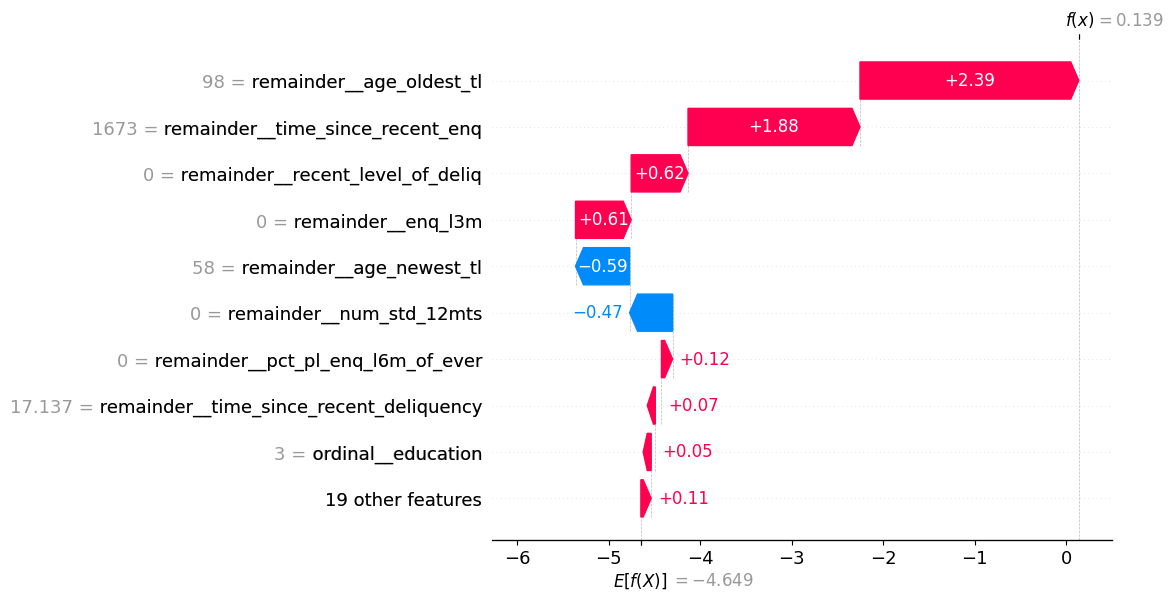

In [114]:
shap.plots.waterfall(shap_values[0,:,0])

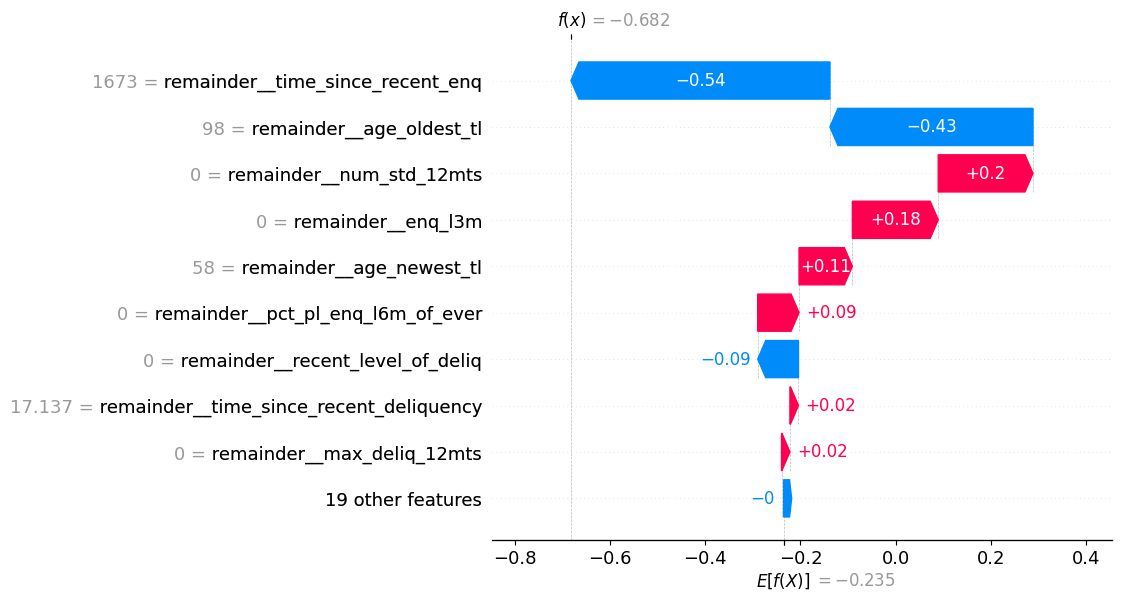

In [115]:
shap.plots.waterfall(shap_values[0,:,1])

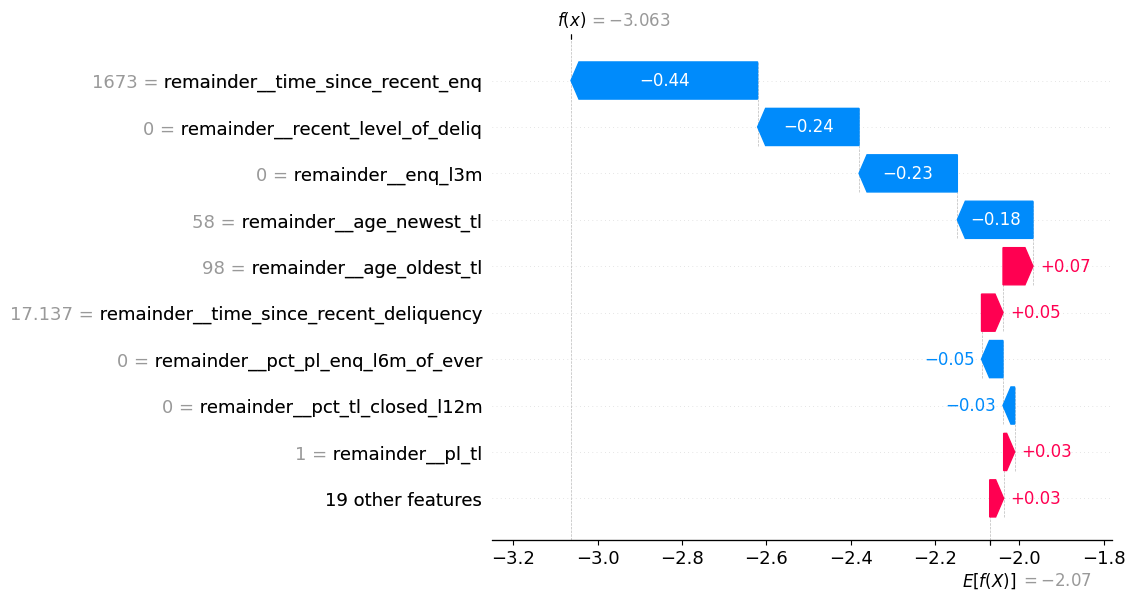

In [116]:
shap.plots.waterfall(shap_values[0,:,2])

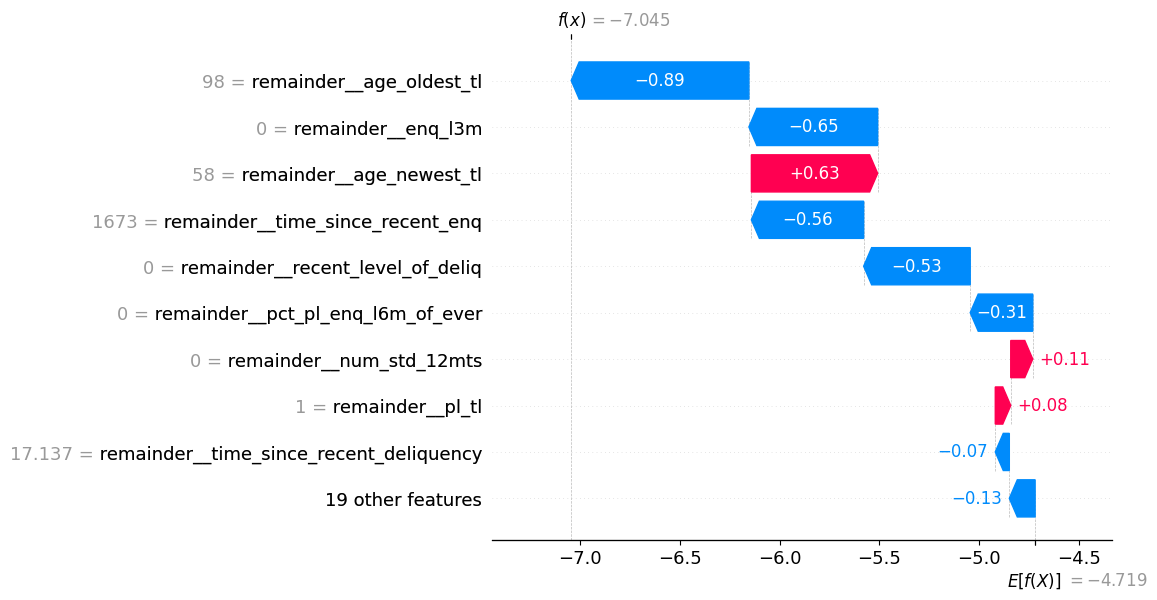

In [117]:
shap.plots.waterfall(shap_values[0,:,3])

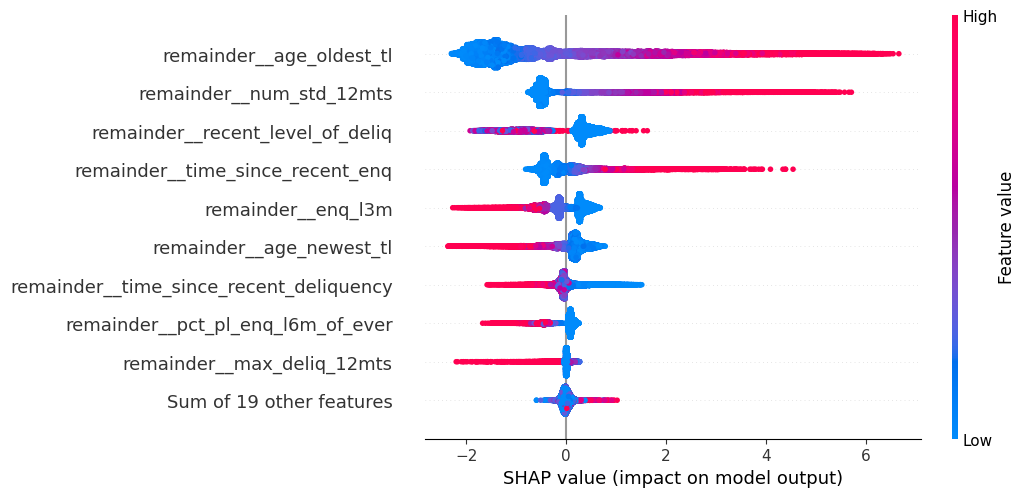

In [120]:
shap.plots.beeswarm(shap_values[:, :, 0])

In [14]:
kf =StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
score = cross_val_score(pipe,xtrain,ytrain,cv=kf,scoring="accuracy")

In [15]:
score.mean()

np.float64(0.8027903840175927)

In [16]:
pipe.fit(xtrain,ytrain)

c:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('pre-processing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['SSC',
                                                                              '12TH',
                                                                              'UNDER '
                                                                              'GRADUATE',
                                                                              'GRADUATE',
                                                                              'POST-GRADUATE',
                                                                              'PROFESSIONAL',
                                                                              'OTHERS']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['education']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['maritalst...
                               feature_weights=None, gamma=None,
                               grow_policy='lossguide', importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.2486165415267274, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=8,
                               max_leaves=None,
                               min_child_weight=0.43602041607476005,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=140,
                               n_jobs=None, ...))])

In [17]:
pred = pipe.predict(xtest)

In [18]:
pred_train = pipe.predict(xtrain)

In [19]:
print(classification_report(lb.inverse_transform(ytrain),lb.inverse_transform(pred_train)))

              precision    recall  f1-score   support

          P1       0.87      0.83      0.85      4668
          P2       0.87      0.95      0.91     25820
          P3       0.63      0.42      0.50      5916
          P4       0.83      0.81      0.82      4664

    accuracy                           0.84     41068
   macro avg       0.80      0.75      0.77     41068
weighted avg       0.83      0.84      0.83     41068



In [20]:
accuracy_score(ytrain,pred_train)

0.8445505016070907

In [21]:
accuracy_score(lb.inverse_transform(ytest),lb.inverse_transform(pred))

0.7938254772107518

In [22]:
print(classification_report(lb.inverse_transform(ytest),lb.inverse_transform(pred)))

              precision    recall  f1-score   support

          P1       0.82      0.78      0.80      1135
          P2       0.84      0.93      0.88      6379
          P3       0.46      0.28      0.35      1536
          P4       0.77      0.74      0.75      1218

    accuracy                           0.79     10268
   macro avg       0.72      0.68      0.70     10268
weighted avg       0.77      0.79      0.78     10268



In [23]:
from sklearn.metrics import confusion_matrix
confusion_matrix(lb.inverse_transform(ytest),lb.inverse_transform(pred), labels=['P1', 'P2', 'P3', 'P4'])

array([[ 889,  246,    0,    0],
       [ 158, 5938,  254,   29],
       [  36,  828,  426,  246],
       [   1,   73,  246,  898]])

In [92]:
import matplotlib.pyplot as plt

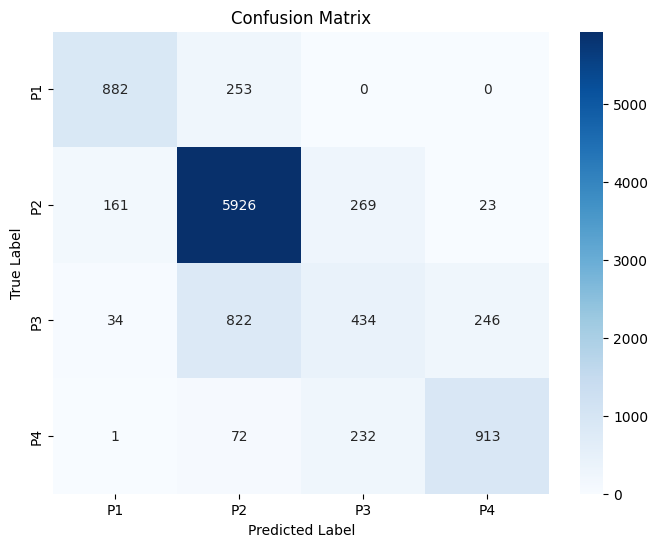

In [94]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['P1', 'P2', 'P3', 'P4'], yticklabels=['P1', 'P2', 'P3', 'P4'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [54]:
df["approved_flag"].value_counts()

approved_flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64

In [109]:
print(classification_report(lb.inverse_transform(ytest),lb.inverse_transform(pred)))

              precision    recall  f1-score   support

          P1       0.83      0.77      0.80      1135
          P2       0.83      0.94      0.88      6379
          P3       0.46      0.25      0.32      1536
          P4       0.78      0.75      0.76      1218

    accuracy                           0.79     10268
   macro avg       0.73      0.68      0.69     10268
weighted avg       0.77      0.79      0.77     10268



In [53]:
pred_prob = pipe.predict_proba(xtest)

In [57]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize true labels
y_test_bin = label_binarize(ytest, classes=[0,1,2,3])  # update based on your labels

# ROC AUC score
score = roc_auc_score(y_test_bin, pred_prob, multi_class='ovr', average='macro')
print(f"Multiclass ROC AUC: {score:.3f}")


Multiclass ROC AUC: 0.937


In [50]:
importance_df = pipe.named_steps["model"].get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame(importance_df.items(), columns=['Feature', 'Importance'])

# Normalize to percentage
importance_df['Importance (%)'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()

# Sort by importance
importance_df = importance_df.sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)

print(importance_df)

   Feature  Importance  Importance (%)
0      f25      1811.0        9.730804
1      f43      1352.0        7.264521
2      f28      1341.0        7.205416
3      f34      1117.0        6.001827
4      f29      1079.0        5.797647
5      f47      1064.0        5.717049
6      f46       995.0        5.346301
7      f27       922.0        4.954059
8      f40       857.0        4.604804
9      f44       848.0        4.556445
10     f26       843.0        4.529579
11     f45       806.0        4.330772
12     f32       439.0        2.358820
13     f22       419.0        2.251357
14     f50       412.0        2.213745
15     f16       370.0        1.988072
16      f0       320.0        1.719413
17     f23       315.0        1.692547
18     f17       310.0        1.665682
19     f24       284.0        1.525979
20     f13       272.0        1.461501
21     f14       264.0        1.418516
22     f42       259.0        1.391650
23     f31       194.0        1.042394
24     f18       165.0   

In [49]:
df.iloc[:,[37]]

,pct_pl_enq_l6m_of_ever
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
51331,0.0
51332,0.0
51333,1.0
51334,0.0


In [18]:
transformer2 = ColumnTransformer(
    [("ordinal",OrdinalEncoder(categories=[["SSC","12TH","UNDER GRADUATE","GRADUATE","POST-GRADUATE","PROFESSIONAL","OTHERS"]],
                    handle_unknown="use_encoded_value",
                    unknown_value= -1,
                    encoded_missing_value=np.nan),["education"]),
     ("onehot",OneHotEncoder(drop="first",sparse_output=False),["maritalstatus","gender","last_prod_enq2","first_prod_enq2"])
]
, remainder="passthrough")

In [39]:
from lightgbm import LGBMClassifier

In [41]:
pipe2 = Pipeline([
    ("pre-processing",transformer2),
    ("model",LGBMClassifier(n_jobs=-1))
    ])

In [20]:
import optuna

In [44]:
def objective(trial):
    n_estimators = trial.suggest_int("model__n_estimators",10,1000)
    max_depth = trial.suggest_int("model__max_depth",2,10)
    subsample = trial.suggest_float("model__subsample",0.1,0.9)
    learning_rate = trial.suggest_float("model__learning_rate",0.001,1)
    reg_lambda = trial.suggest_int("model__reg_lambda",1,1000)
    colsample_bylevel = trial.suggest_float("model__colsample_bylevel",0.2,0.8)
    eta = trial.suggest_float("model__eta",0.1,1)
    grow_policy = trial.suggest_categorical("model__grow_policy",["depthwise","lossguide"])
    min_child_weight = trial.suggest_float("model__min_child_weight",0.1,1)


    pipe2 = Pipeline([
    ("pre-processing",transformer2),
    ("model",LGBMClassifier(n_jobs=-1,n_estimators=n_estimators,max_depth=max_depth,
                           subsample=subsample,learning_rate=learning_rate,reg_lambda=reg_lambda,
                           colsample_bylevel=colsample_bylevel,eta=eta))
    ])
    score = cross_val_score(pipe2,xtrain,ytrain,cv=2,scoring="accuracy").mean()
    return score

In [45]:
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=20)

[I 2025-07-06 16:08:28,722] A new study created in memory with name: no-name-5945ab7b-613f-4db2-995b-078dee3e90e5
c:\Users\Rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-07-06 16:08:53,960] Trial 0 finished with value: 0.7906399142884971 and parameters: {'model__n_estimators': 886, 'model__max_depth': 10, 'model__subsample': 0.6478690251621665, 'model__learning_rate': 0.6950851412984461, 'model__reg_lambda': 417, 'model__colsample_bylevel': 0.30516582284023436, 'model__eta': 0.5596629574256671, 'model__grow_policy': 'lossguide', 'model__min_child_weight': 0.994400932961452}. Best is trial 0 with

In [46]:
study.best_params

{'model__n_estimators': 140,
 'model__max_depth': 8,
 'model__subsample': 0.3692321814052427,
 'model__learning_rate': 0.2486165415267274,
 'model__reg_lambda': 302,
 'model__colsample_bylevel': 0.6364993625552667,
 'model__eta': 0.9956631118988113,
 'model__grow_policy': 'lossguide',
 'model__min_child_weight': 0.43602041607476005}

In [55]:
study.best_value

0.8002824583617415

In [53]:
ss = study.trials_dataframe()

In [54]:
ss.to_csv("model_results.csv")

In [42]:
study.best_params

{'model__n_estimators': 72,
 'model__max_depth': 3,
 'model__subsample': 0.39368706704982687}

In [43]:
study.best_value

0.7998684666506334